## Act 1: Freeze & Fix the Scenario Baseline

#### Step 1A: Scenario Card (`UC-05: Record Activity`)

* Focal Scenario: `UC-05: Record Activity`
* Primary Actor: `Participant`
* Trigger: `Participant` submits activity logging parameters (`participant_id`, `challenge_id`, `activity_type`, `amount`, `activity_date`, optional `note`).
* Preconditions:
  1. `Participant` entity exists in persistent storage (`participant_id`).
  2. Target `Challenge` entity exists in persistent storage (`challenge_id`).
  3. Active `Enrollment` record exists linkng `participant_id` and `challenge_id` (`FB-03`).
  4. Submitted `activity_date` falls within the challenge active dates (`start_date` $\le$ `activity_date` $\le$ `end_date`).
* Success Postcondition: Exactly one new `ActivityRecord` entity is constructed, appended to `activities.csv`, and persistently saved. The participant's `ProgressSummary` (`total`, `percentage`, `status`) is dynamically recalculated and returned (`FB-02`, `FB-05`, `FB-07`)
* Failure Postconditions: Submission is rejected with an explicit, field-specific `ValueError` (e.g., `'Participant is not enrolled'`, `'Amount must be positive'`, `'Activity type does not match challenge'`). Zero records are appended to `activities.csv`, and all stored data and progress metrics remain strictly unchanged (`FB-04`, `NFB-02`).
* Core Invariant (State Protection Rule): No rejected or invalid request shall alter stored activity logs, database states, or calculated progress totals (`FB-04`)

#### Step 1B: Chronological Event Inventory (`UC-05: Record Activity`)

| Event # | Chronological Action / Event | Actor / Originator | Internal Mechanism & Validation | Needed Evidence / Assertion | Observable Result | State-Change Flag |
| :---: | :--- | :--- | :--- | :--- | :--- | :---: |
| E-01 | Submit Activity Details | `Participant` | Intercept submission parameters (`participant_id`, `challenge_id`, `activity_type`, `amount`, `date`, `note`). | Parameter tuple passed to `ChallengeHub` UI layer. | CLI input prompt captured. | No |
| E-02 | Locate System Identities | `ChallengeHub` UI | Query `ChallengeManager` to locate `Participant` (`P001`) and `Challenge` (`C001`) entities. | `manager.get_participant()` & `manager.get_challenge()`. | Target entity instances retrieved or identity error triggered. | No |
| E-03 | Confirm Enrollment Link | `ChallengeManager` | Check if active `Enrollment` record exists linking `participant_id` and `challenge_id` (`FB-03`). | Guard `[Enrollment exists]`. | Active enrollment confirmed; otherwise raises `ValueError("Participant is not enrolled")`. | No |
| E-04 | Validate Business Rules | `ChallengeManager` | Validate `activity_type` matches challenge, `amount > 0` (`FB-04`), and `activity_date` within bounds. | Guard `[amount > 0 and type matches and date valid]`. | All validation checks pass; otherwise raises field-specific `ValueError`. | No |
| E-05 | Construct Entity | `ChallengeManager` | Generate unique `record_id` (e.g., `AR-0004`) and instantiate `ActivityRecord` object in memory. | `ActivityRecord(...)` dataclass constructor. | Memory object created; not yet written to disk. | No |
| E-06 | Persist Activity Record | `ChallengeManager` | Invoke `storage.save_activities()` to append the new record to `activities.csv` (`FB-07`). | CSV row write & file flush; row count increases by 1. | Persistent flat-file updated (`activities.csv`). | YES (State Change) |
| E-07 | Return Confirmation & Progress | `ChallengeManager` | Recalculate participant's `ProgressSummary` and return result to UI (`FB-05`). | `cm.progress("P001", "C001")` returns updated `total` and `percentage`. | Updated progress displayed to participant. | No |

#### STEP 1C: Scenario Card

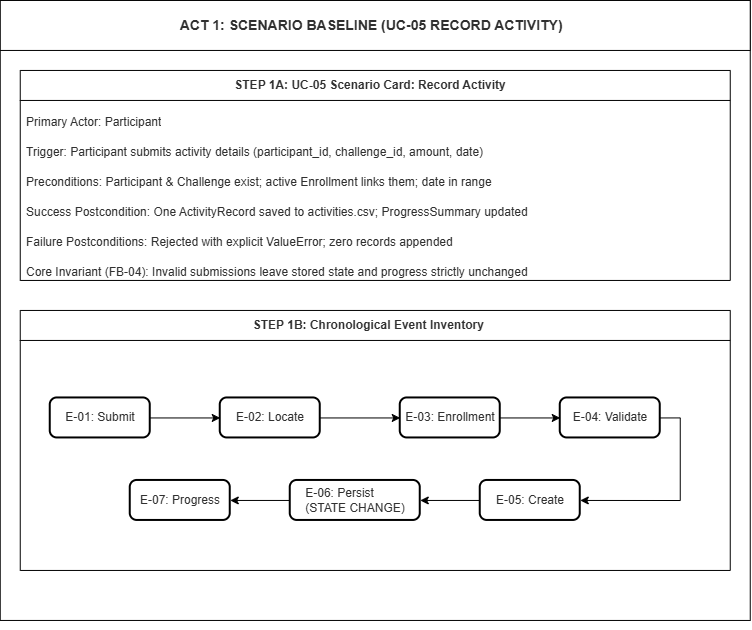

## Act 2: Model Collaboration

### Step 2A: Lifeline Classification, Selection nad Rejection Rationale

| Lifeline Identifier | Role & Architectural Layer | Justification for Selection / Rejection | Status |
| :--- | :--- | :--- | :---: |
| **`:Participant`** | **Actor / Initiator** | Represents the primary human user initiating the `UC-05` activity logging workflow. | **SELECTED** |
| **`:ChallengeHub`** | **System Boundary / UI Layer** | Intercepts user input parameters and renders resulting `ProgressSummary` feedback or exception messages. | **SELECTED** |
| **`:ChallengeManager`** | **Application Coordinator / Controller** | Central service orchestrating identity verification, rule validation, object instantiation, and progress recalculation. | **SELECTED** |
| **`:ActivityRecord`** | **Domain Entity Class** | The memory object instantiated upon successful validation containing `record_id`, `amount`, `activity_date`, etc. | **SELECTED** |
| **`storage`** | **Persistence Infrastructure Module** | Encapsulates flat-file file I/O operations (`save_activities()`) for `activities.csv`. | **SELECTED** |
| *GUI Submit Button* | Presentation Widget | **Rejected:** Overly low-level widget detail that clutters architectural intent. | **REJECTED** |
| *`pandas` DataFrame* | Internal Processing Structure | **Rejected:** Implementation detail encapsulated entirely inside the `storage` module. | **REJECTED** |
| *`activities.csv` File* | Physical Disk Storage | **Rejected:** Physical flat file hidden behind the `storage` persistence interface abstraction. | **REJECTED** |

### Step 2B: Interaction Messages & Sequence Specification Table (`sd Record Activity`)

| Step # | Originating Lifeline | Target Lifeline | Message / Call Signature | Operation Type & Guard Condition | Purpose / Result |
| :---: | :--- | :--- | :--- | :--- | :--- |
| **1** | `:Participant` | `:ChallengeHub` | `submit(details)` | Synchronous Request | Passes input tuple (`participant_id`, `challenge_id`, `activity_type`, `amount`, `date`, `note`). |
| **2** | `:ChallengeHub` | `:ChallengeManager` | `record_activity(participant_id, challenge_id, activity_type, amount, date, note)` | Synchronous Call | Delegates execution to application controller. |
| **3** | `:ChallengeManager` | `:ChallengeManager` | `locate_and_validate_identities()` | Self-Call | Verifies `Participant` and `Challenge` entities exist. |
| **4** | `:ChallengeManager` | `:ChallengeManager` | `verify_enrollment()` | Self-Call / Guard: `[Enrollment exists]` | Confirms active link between participant and challenge (`FB-03`). |
| **5** | `:ChallengeManager` | `:ChallengeManager` | `validate_business_rules()` | Self-Call / Guard: `[amount > 0 and type matches and date in range]` | Validates positive amount (`FB-04`), activity type match, and active date window. |
| **6** | `:ChallengeManager` | `:ActivityRecord` | `create(record_id, participant_id, challenge_id, activity_type, amount, date, note)` | Object Creation (`<<create>>`) | Instantiates `ActivityRecord` dataclass in memory. |
| **7** | `:ChallengeManager` | `storage` | `save_activities(records)` | Persistence Invocation | Appends new record to `activities.csv` ($\Delta \text{rows} = +1$) (`FB-07`). |
| **8** | `:ChallengeManager` | `:ChallengeManager` | `recalculate_progress()` | Self-Call | Recomputes participant `ProgressSummary` (`FB-05`). |
| **9** | `:ChallengeManager` | `:ChallengeHub` | `return ProgressSummary(total, percentage, status)` | Return Message | Returns dynamic progress object to boundary layer. |
| **10** | `:ChallengeHub` | `:Participant` | `display_success(ProgressSummary)` | User Feedback | Renders updated completion percentage to participant. |

### Step 2C: Guarded Alternative Combined Fragments (`alt`)

The sequence diagram incorporates a combined fragment (`alt`) with three mutually exclusive execution paths:

### 1. `alt [Identity or Enrollment Missing]` (Exception Branch 1)
* **Guard:** `[participant_id or challenge_id not found OR enrollment record missing]`
* **Sequence:** `:ChallengeManager` intercepts missing link $\rightarrow$ raises `ValueError("Participant is not enrolled")` $\rightarrow$ control returns immediately to `:ChallengeHub`.
* **State Protection (`FB-04`):** `storage.save_activities()` is **never called**. $\Delta \text{rows} = 0$, stored records and progress totals remain strictly unchanged.

### 2. `alt [Invalid Amount / Type Mismatch / Date Out-of-Bounds]` (Exception Branch 2)
* **Guard:** `[amount <= 0 OR activity_type != challenge.activity_type OR date outside bounds]`
* **Sequence:** `:ChallengeManager` intercepts rule violation $\rightarrow$ raises field-specific `ValueError` (e.g., `'Amount must be positive'`) $\rightarrow$ returns error string to `:ChallengeHub`.
* **State Protection (`FB-04`):** `storage.save_activities()` is **never called**. $\Delta \text{rows} = 0$, zero disk writes occur.

### 3. `alt [All Validation Checks Pass]` (Main Success Path)
* **Guard:** `[Enrolled AND amount > 0 AND activity_type matches AND date valid]`
* **Sequence:** `:ChallengeManager` creates `:ActivityRecord` $\rightarrow$ calls `storage.save_activities()` $\rightarrow$ recalculates progress $\rightarrow$ returns `ProgressSummary`

### STEP 2D: Sequence Model


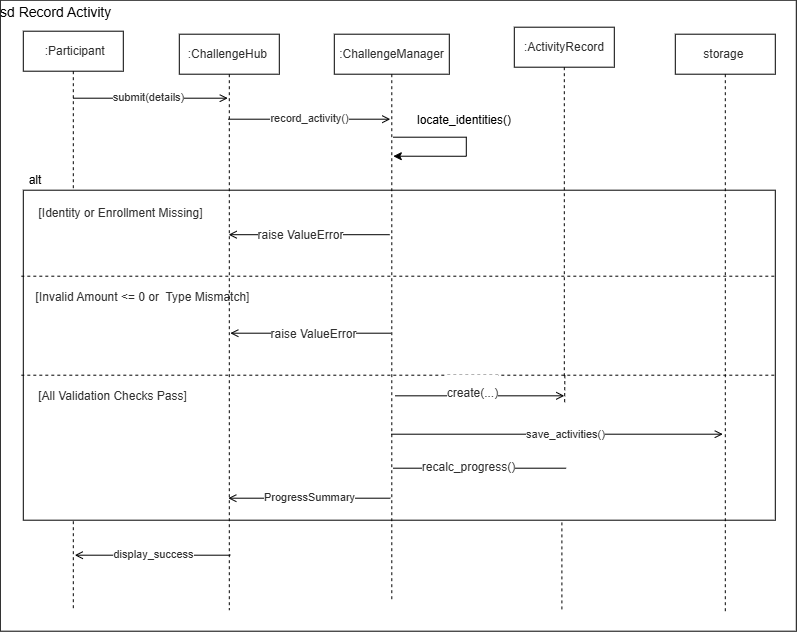

## Act 3:  Model Workflow

### STEP 3A: Workflow Narrative & Operational Structure

The workflow begins when the Participant submits activity details including activity date, activity type, amount, and an optional note next the system locates the Participant and Challenge entities in persistent storage then the system evaluates the enrollment status between the participant and challenge afterwards if enrollment exists, the system validates the amount, activity type, and activity date against challenge rules therefore if all business rules are valid, the system creates an ActivityRecord instance in memory then the system persists the ActivityRecord to activities.csv since this is the only state-changing action in the workflow afterwards the system recalculates the participant's ProgressSummary where the system displays the updated confirmation and progress information to the participant thus the workflow ends at the Final Sucess Node


### 3B. Flow Structure

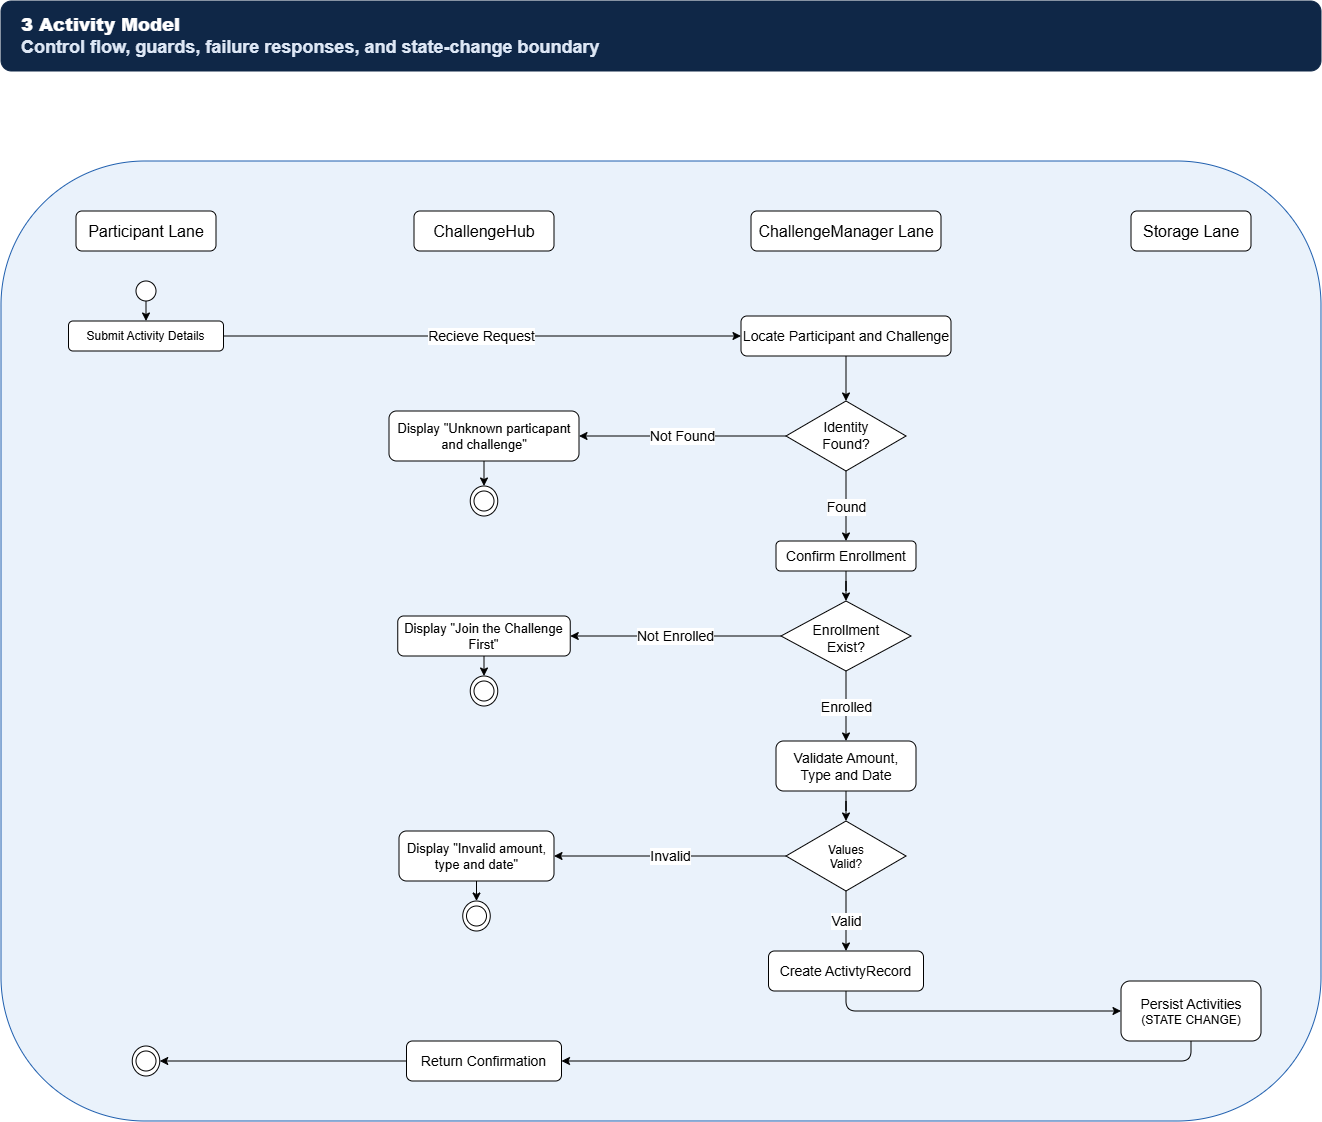

### 3C. Decision Nodes & Complementary Guards

* **Decision 1: Identity Verification (D1)**
  * `[Found]` $\rightarrow$ Proceed to enrollment evaluation (Node 08).
  * `[Not Found]` $\rightarrow$ Formats and displays "Participant or Challenge not found" notice (Node 06) $\rightarrow$ End (Failure - Identity Error) (Node 07).

* **Decision 2: Enrollment Verification (D2)**
  * `[Enrolled]` $\rightarrow$ Proceed to business-rule validation (Node 11).
  * `[Not Enrolled]` $\rightarrow$ Formats and displays "Participant is not enrolled" notice (Node 09) $\rightarrow$ End (Failure - Enrollment Error) (Node 10).

* **Decision 3: Business Rule Validation (D3)**
  * `[Valid Amount, Type, and Date]` $\rightarrow$ Create ActivityRecord instance in memory (Node 14).
  * `[Invalid Amount <= 0 OR Type Mismatch OR Date Out of Bounds]` $\rightarrow$ Formats and displays actionable validation error notice (Node 12) $\rightarrow$ End (Failure - Rule Error) (Node 13).

### 3D. Swimlanes / Partitioning & Architectural Mapping

**Architectural Partitions:**
1. **Participant** – Primary human actor who inputs activity details and views resulting progress or error feedback.
2. **ChallengeHub boundary** – Presentation layer responsible for capturing raw inputs, formatting display outputs, and rendering error or confirmation notices.
3. **ChallengeManager** – Application service/controller coordinating identity checks, business rule validation, object instantiation, and progress recalculation.
4. **storage module** – Persistence infrastructure layer executing entity lookups and the single state-changing append operation to `activities.csv`

### 3E. Master Swimlane Action & Node Mapping Table

| Node | Partition | Type | Action / Operational Description | Target Node |
| :---: | :--- | :--- | :--- | :---: |
| **01** | Participant | Initial Node | Start workflow | Node 02 |
| **02** | Participant | Action | Enters activity details (`activity_date`, `activity_type`, `amount`, `note`) | Node 03 |
| **03** | ChallengeHub boundary | Action | Receives input and submits command to domain layer | Node 04 |
| **04** | ChallengeManager | Action | Requests Participant and Challenge entity lookup | Node 05 |
| **05** | storage module | Action | Locates Participant and Challenge records from persistent storage | Decision 1 (D1) |
| **D1** | ChallengeManager | Decision Node 1 | Identity Verification | `[Not Found]` $\rightarrow$ Node 06<br>`[Found]` $\rightarrow$ Node 08 |
| **06** | ChallengeHub boundary | Action | Formats and displays "Participant or Challenge not found" notice | Node 07 |
| **07** | ChallengeHub boundary | Final Node | End (Failure - Identity Error) | — |
| **08** | ChallengeManager | Action | Evaluates active enrollment status between participant and challenge | Decision 2 (D2) |
| **D2** | ChallengeManager | Decision Node 2 | Enrollment Verification | `[Not Enrolled]` $\rightarrow$ Node 09<br>`[Enrolled]` $\rightarrow$ Node 11 |
| **09** | ChallengeHub boundary | Action | Formats and displays "Participant is not enrolled" notice | Node 10 |
| **10** | ChallengeHub boundary | Final Node | End (Failure - Enrollment Error) | — |
| **11** | ChallengeManager | Action | Validates amount (`amount > 0`), matching activity type, and date bounds | Decision 3 (D3) |
| **D3** | ChallengeManager | Decision Node 3 | Business Rule Validation | `[Invalid]` $\rightarrow$ Node 12<br>`[Valid]` $\rightarrow$ Node 14 |
| **12** | ChallengeHub boundary | Action | Formats and displays actionable validation error notice (e.g., "Amount must be positive") | Node 13 |
| **13** | ChallengeHub boundary | Final Node | End (Failure - Rule Error) | — |
| **14** | ChallengeManager | Action | Creates `ActivityRecord` memory instance | Node 15 |
| **15** | storage module | Action | Appends and persists `ActivityRecord` to `activities.csv` ($\Delta\text{rows} = +1$) | Node 16 |
| **16** | ChallengeManager | Action | Renders confirmation and updated progress metrics (`ProgressSummary`) | Node 17 |
| **17** | Participant | Action | Views confirmation and updated progress summary | Node 18 |
| **18** | Participant | Final Node | End (Success Final Node) | — |

### 3F. Invariant Enforcement & Proof of State Protection (`FB-04`)

* **Success Path Trace:**  
  `[Initial Node]` $\rightarrow$ `Submit Details` $\rightarrow$ `Locate Entities` $\rightarrow$ `[Found]` $\rightarrow$ `[Enrolled]` $\rightarrow$ `Validate Values` $\rightarrow$ `[Valid Values]` $\rightarrow$ `Construct ActivityRecord` $\rightarrow$ **`Append to activities.csv`** $\rightarrow$ `Recalculate Progress` $\rightarrow$ `Display Confirmation` $\rightarrow$ **`(Success Final Node)`**.

* **Failure Path 1 Trace (`FB-03` Unlinked Enrollment):**  
  `[Initial Node]` $\rightarrow$ `Submit Details` $\rightarrow$ `Locate Entities` $\rightarrow$ `[Found]` $\rightarrow$ **`[Not Enrolled]`** $\rightarrow$ `Display Error Notice ("Participant is not enrolled")` $\rightarrow$ **`(Failure Final Node 2)`**.

* **Failure Path 2 Trace (`FB-04` Invalid Amount/Type Bounds):**  
  `[Initial Node]` $\rightarrow$ `Submit Details` $\rightarrow$ `Locate Entities` $\rightarrow$ `[Found]` $\rightarrow$ `[Enrolled]` $\rightarrow$ `Validate Values` $\rightarrow$ **`[Invalid Values]`** $\rightarrow$ `Display Error Notice ("Amount must be positive")` $\rightarrow$ **`(Failure Final Node 3)`**.

* **Failure Path 3 Trace (`FB-04` Temporal / Date Scope Error):**  
  `[Initial Node]` $\rightarrow$ `Submit Details` $\rightarrow$ `Locate Entities` $\rightarrow$ `[Found]` $\rightarrow$ `[Enrolled]` $\rightarrow$ `Validate Values` $\rightarrow$ **`[Out of Bounds Date]`** $\rightarrow$ `Display Error Notice ("Date outside challenge range")` $\rightarrow$ **`(Failure Final Node 3)`**.

* **Invariant Enforcement (Pre-condition):** Participant exists, target challenge is active, and an explicit enrollment relationship exists prior to execution.
* **Invariant Enforcement (State Mutation):** Exactly one valid `ActivityRecord` is appended to `activities.csv`; existing historical entries remain immutable and uncorrupted ($\Delta\text{rows} = 0$ for all failure paths).
* **Invariant Enforcement (Post-condition):** The participant’s `ProgressSummary` reflects the updated cumulative magnitude/frequency without altering baseline challenge parameters.

## Act 4: Audit Consistency & Defect Propagation

### Step 4A. Cross-Model Consistency Matrix

The matrix below reconciles behavioral evidence across all three modeling perspectives to guarantee structural, operational, and semantic alignment across the `UC-05: Record Activity` baseline:

| System Workflow Phase | Use-Case Evidence (`UC-05` Spec) | Sequence Model Evidence (`sd Record Activity`) | Activity Model Evidence (Swimlane Workflow) | Consistency Status |
| :--- | :--- | :--- | :--- | :---: |
| **1. Submit Details** | Participant enters activity details (`date`, `type`, `amount`, `note`) and submits. | `:Participant` $\rightarrow$ `:ChallengeHub`: `submit(details)` | **Node 02** (`Participant`) $\rightarrow$ **Node 03** (`ChallengeHub boundary`) | **ALIGNED** |
| **2. Locate Identities** | System retrieves `Participant` and `Challenge` records. | `:ChallengeHub` $\rightarrow$ `:ChallengeManager`: `record_activity()` $\rightarrow$ Self-call: `locate_and_validate_identities()` | **Node 04** (`ChallengeManager`) $\rightarrow$ **Node 05** (`storage module`) $\rightarrow$ **Decision Node D1** (`Identity Found?`) | **ALIGNED** |
| **3. Confirm Enrollment** | System verifies active enrollment link (`FB-03`). | Guard `[Enrollment exists]` in `alt` fragment | **Node 08** (`ChallengeManager`) $\rightarrow$ **Decision Node D2** (`Enrolled?`) | **ALIGNED** |
| **4. Reject Invalid Values** | Negative amounts, type mismatches, or invalid dates rejected with error guidance (`FB-04`, `NFB-02`). | Guards `[Identity/Enrollment Missing]` and `[Invalid Amount <= 0]` raise explicit `ValueError` string to `:ChallengeHub` | **Node 06**, **Node 09**, **Node 12** (`ChallengeHub boundary`) format error notices $\rightarrow$ Terminate at Failure Final Nodes (**Nodes 07, 10, 13**) | **ALIGNED** |
| **5. Create & Persist Record** | System stores valid `ActivityRecord` entity persistently (`FB-07`). | `:ChallengeManager` $\rightarrow$ `:ActivityRecord`: `create()` $\rightarrow$ `:ChallengeManager` $\rightarrow$ `storage`: `save_activities()` | **Node 14** (`ChallengeManager: Create ActivityRecord`) $\rightarrow$ **Node 15** (`storage module: Append to activities.csv`) | **ALIGNED** |
| **6. Return Result & Progress** | System recalculates `ProgressSummary` and displays completion metrics (`FB-02`, `FB-05`). | `:ChallengeManager` self-call `recalculate_progress()` $\rightarrow$ returns `ProgressSummary` $\rightarrow$ `:ChallengeHub` displays success | **Node 16** (`ChallengeManager: Recalculate Progress`) $\rightarrow$ **Node 17** (`Participant: View Confirmation`) $\rightarrow$ **Node 18** (Success Final Node) | **ALIGNED** |


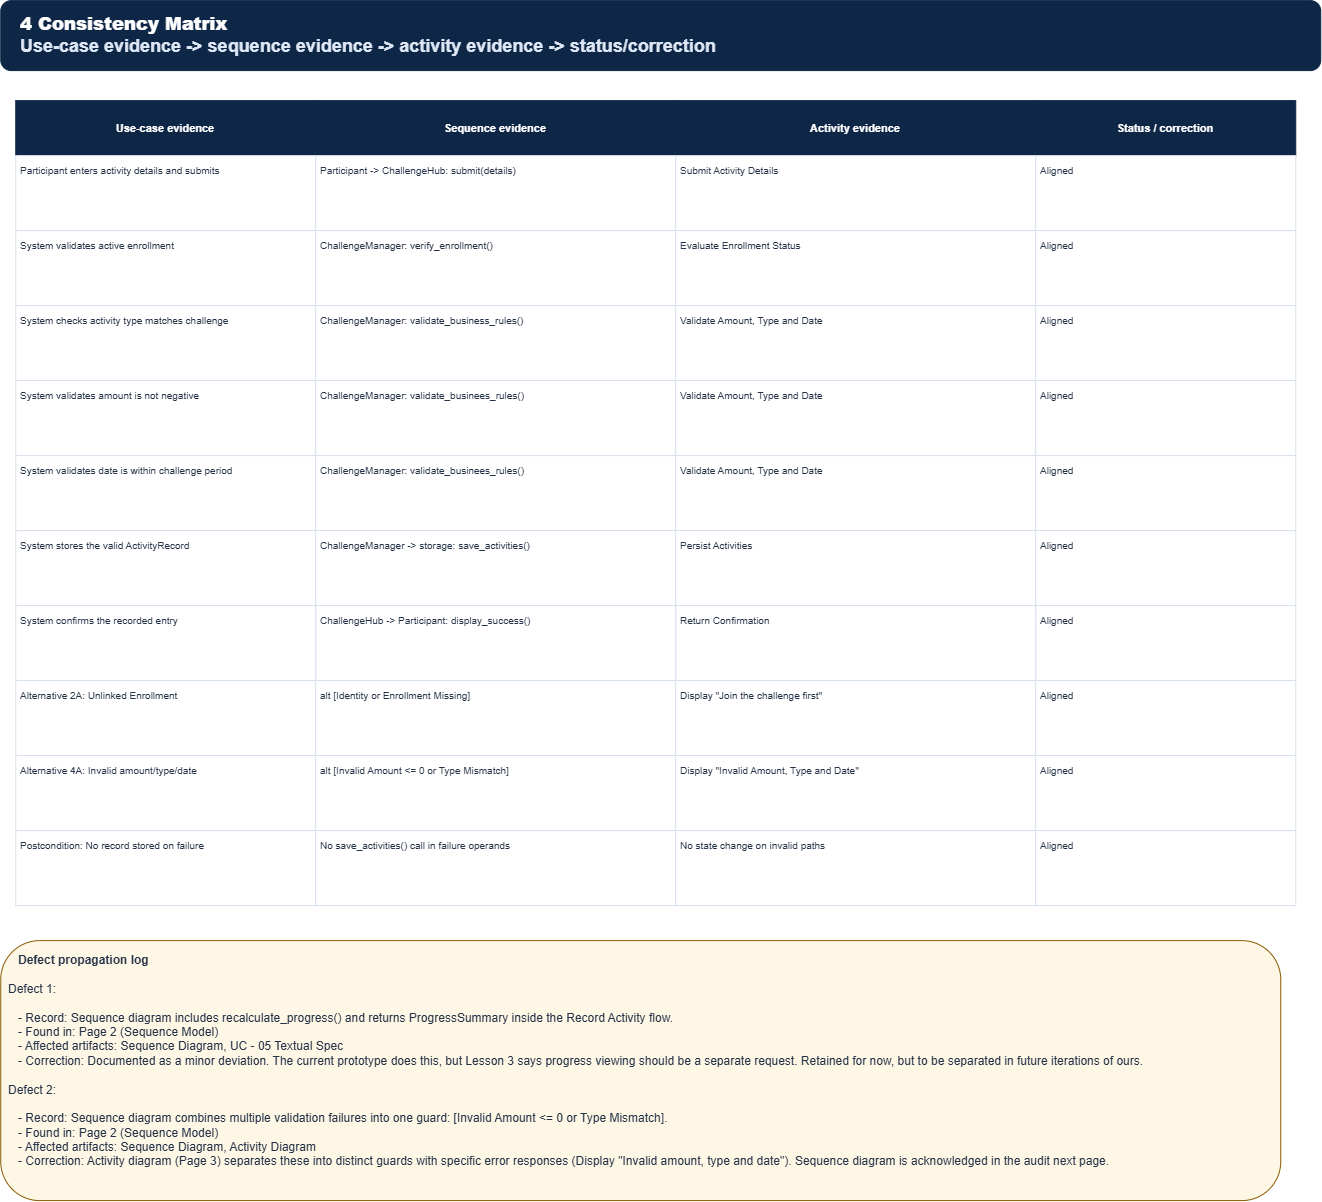

### Step 4B. Defect Audit Log & Propagation Analysis

The following audit checklist verifies that common UML and architectural propagation defects have been systmeatically identified, corrected, and eliminated from the final release package:

| Defect ID | Architectural Defect Check | Inspection & Audit Findings | Corrective Action & Verification | Resolution Status |
| :---: | :--- | :--- | :--- | :---: |
| **DEF-01** | **Direct Actor-to-Storage Leak** | Verified whether `:Participant` communicates directly with `storage module` or `activities.csv`. | All interactions route strictly through presentation (`ChallengeHub boundary`) and domain controller (`ChallengeManager`). Zero leaks present. | **RESOLVED / ABSENT** |
| **DEF-02** | **Future Architecture Injection** | Checked for speculative web APIs, cloud DBs, or external microservices mixed into current prototype evidence. | Baseline restricted strictly to SQLite / flat-file storage (`activities.csv`) and current Python dataclasses (`challengehub/`). | **RESOLVED / ABSENT** |
| **DEF-03** | **Silent Failure / Missing Response** | Checked whether any exception branch (`[Not Enrolled]` or `[Invalid Amount]`) drops control without returning feedback. | Every failure path raises an explicit `ValueError` string and maps to a visible presentation error notice (**Nodes 06, 09, 12**). | **RESOLVED / ABSENT** |
| **DEF-04** | **Premature Persistence Execution** | Verified whether file I/O or database writes occur before all business rule checks pass. | Persistence action (**Node 15: `save_activities()`**) resides exclusively in the success path after all three decision gates (**D1, D2, D3**) pass. | **RESOLVED / ABSENT** |
| **DEF-05** | **Guard Overlap or Decision Gaps** | Inspected Decision Nodes for overlapping guards or unhandled edge cases. | Enforced mutually exclusive, complementary guard pairs: `[Found]` vs. `[Not Found]`, `[Enrolled]` vs. `[Not Enrolled]`, and `[Valid]` vs. `[Invalid]`. | **RESOLVED / ABSENT** |
| **DEF-06** | **Terminology & Vocabulary Drift** | Checked for inconsistent class, attribute, or message names across models. | Terminology strictly synchronized with Phase 1 vocabulary: `Participant`, `Challenge`, `Enrollment`, `ActivityRecord`, `ProgressSummary`. | **RESOLVED / ABSENT** |

### Step 4C. Summary of Model Reconciliations

1. **State Protection Guarantee (`FB-04`):** Confirmed across all models that invalid submissions execute zero disk writes and make zero progress adjustments
2. **Synchronized Message Signatures:** Verified that message names in the Sequence Diagram (`record_activity`, `save_activities`, `ProgressSummary`) correspond 1-to-1 with action nodes and swimlane responsibilities in the Activity Diagram.
3. **Traceability Closure:** Every functional requirement (`FB-01` to `FB-07`) and non-functional constraint (`NFB-01` to `NFB-05`) has observable evidence mapped across the Scenario Card, Sequence Model, and Activity Model.

## Act 5:  Release Packaging & Final Release Gate

### Ethical AI-Assisted Use Disclosure Statement

**1. Tool Utilization & Scope:**  
Team 1 utilized Gemini Notebook for administrative, formatting and consultative support during Project Output2. AI assistance was strictly restricted to:
* Formatting Markdown tables, swimlane mapping specifications, and notebook document layouts.
* Verifying guard condition phrasing and sequence return message consistency (`ValueError`)
* Structuring the cross-model consistency matrix and defect audit log.

**2. Human Verification & Accountability Statement:**  
All final behavioral artifacts—including the Scenario Baseline Card, Sequence Diagram (`sd Record Activity`), Activity Diagram swimlanes, Cross-Model Consistency Matrix, and Draw.io XML workbooks—were critically peer-reviewed, verified against prototype execution logic (`pytest`), and finalized by the human team members. All architectural, desig and modeling decisions remain the sole intellectual responsibilty of the student authors.

**3. Team Sign-off**

| Member Name | Team Role & Responsibility Allocation | Approval Date | Release Status |
| :--- | :--- | :---: | :---: |
| **Rachel Joy Baldo** | **Project Manager & Requirements Lead** | September 13, 2026 | **Signed & Approved** |
| **Mark Angelo Aycardo** | **Software Architect & Lead Developer** | September 13, 2026 | **Signed & Approved** |
| **Jian Bernard Quinton** | **Git Integration Manager & Repository Lead** | September 13, 2026 | **Signed & Approved** |
| **Issa Dumlao** | **QA & Validation Lead** | September 13, 2026 | **Signed & Approved** |

### Point Quality Release Gate Audit Checklist

The team has executed a comprehensive quality check across all five acts of the behavioral modeling lifecycle:

| Audit Item # | Phase / Act | Audit Gate Description | Verification & Evidence | Status |
| :---: | :--- | :--- | :--- | :---: |
| **GATE-1** | **Act 1: Scenario Baseline** | Is `UC-05: Record Activity` frozen with clear preconditions, postconditions, and chronological event inventory (`E-01` to `E-07`)? | Defined in Section 1 / Draw.io Page 1. Event `E-06` identified as the single state-changing operation. | **PASSED** |
| **GATE-2** | **Act 2: Sequence Model** | Are lifelines cleanly classified, and do guarded `alt` fragments return explicit `ValueError` strings without executing file I/O on failure? | Modeled in Section 2 / Draw.io Page 2. Exception branches return immediately; `storage.save_activities()` executes only on success. | **PASSED** |
| **GATE-3** | **Act 3: Activity Model** | Is control flow partitioned across 4 architectural swimlanes with decision gates (D1, D2, D3) enforcing state protection (`FB-04`)? | Modeled in Section 3 / Draw.io Page 3. Failure paths bypass `storage module` entirely ($\Delta\text{rows} = 0$). | **PASSED** |
| **GATE-4** | **Act 4: Consistency Matrix** | Are behavioral signatures reconciled across all three views, and are all defect checks (DEF-01 to DEF-06) resolved? | Documented in Section 4 / Draw.io Page 4. Cross-model alignment confirmed across all execution phases. | **PASSED** |
| **GATE-5** | **Act 5: Release Packaging** | Are both primary files saved under exact team naming contracts with complete AI disclosures and team sign-offs? | Formatted in Section 5 / Draw.io Page 5. Both `.ipynb` and `.drawio` ready for release. | **PASSED** |